In [1]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

from transformers_sae import _autoreload
from transformers_sae.ops import MemoryTrackingMode
from transformers_sae.replacement_model import GemmaReplacement, make_replacement_model

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 2
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 2

model_id = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
training_dataset = load_dataset(
    "monology/pile-uncopyrighted-parquet",
    split="train",
    streaming=True,
    columns=["text"],
)
validation_dataset = load_dataset(
    "monology/pile-test-val",
    split="validation",
    revision="refs/convert/parquet",
    streaming=True,
    columns=["text"],
)

with MemoryTrackingMode() as mtm:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map=TRAINING_DEVICE,
        dtype=torch.bfloat16,
        use_safetensors=True,
        # quantization_config=BitsAndBytesConfig(
        #     load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16
        # ),
    )
    model = make_replacement_model(
        model,
        {},
        num_layers=model.config.num_hidden_layers,
        context_length=1024,  # model.config.max_position_embeddings,
        d_model=model.config.hidden_size,
        layer_path="model.layers",
        replacement_class=GemmaReplacement,
    )

print(model)
print(mtm.memory_max)
print(mtm.memory_cur)

/cloud-dev/.venv/lib/python3.13/site-packages/codefind/registry.py:46: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, types.FunctionType):


Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

GemmaReplacementInstance(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforward_layernorm): Gemm

In [2]:
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
# to match Gemma Scope
D_SAE = 16384
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

In [15]:
from concurrent.futures import ThreadPoolExecutor
from transformers_sae.ops import find_latest_checkpoint, load_checkpoint

checkpoint_dir = "/workspace/sae_checkpoints/gemma_2_2b/next_layer/"

saes = {}

def load_layer_checkpoint(layer):
    checkpoint = find_latest_checkpoint(checkpoint_dir, layer)
    if checkpoint is not None:
        sae = load_checkpoint(checkpoint).sae
        sae.eval()
        sae.onload()
        print(f"Loaded checkpoint for layer {layer}")
        return layer, sae
    else:
        print(f"No checkpoint found for layer {layer}")
        return layer, None

# Load the latest checkpoints for each layer in parallel
with ThreadPoolExecutor(max_workers=4) as executor:
    results = executor.map(load_layer_checkpoint, range(model.num_layers - 1, -1, -1))
    for layer, sae in results:
        if sae is not None:
            saes[layer] = sae


Loaded checkpoint for layer 8
Loaded checkpoint for layer 21
Loaded checkpoint for layer 1
Loaded checkpoint for layer 6
Loaded checkpoint for layer 19
Loaded checkpoint for layer 4
Loaded checkpoint for layer 15
Loaded checkpoint for layer 24
Loaded checkpoint for layer 18
Loaded checkpoint for layer 5
Loaded checkpoint for layer 25
Loaded checkpoint for layer 7
Loaded checkpoint for layer 3
Loaded checkpoint for layer 13
Loaded checkpoint for layer 16
Loaded checkpoint for layer 20
Loaded checkpoint for layer 2
Loaded checkpoint for layer 17
Loaded checkpoint for layer 9
Loaded checkpoint for layer 10
Loaded checkpoint for layer 22
Loaded checkpoint for layer 14
Loaded checkpoint for layer 12
Loaded checkpoint for layer 0
Loaded checkpoint for layer 11
Loaded checkpoint for layer 23


In [21]:
# import numpy as np

# from transformers_sae.validation import run_validations

# validations = run_validations(
#     model,
#     tokenizer,
#     saes,
#     validation_dataset,
#     TOKENIZER_BATCH_SIZE,
#     TRAINING_BATCH_SIZE,
#     NUM_VALIDATION_TOKENS,
#     cache_dir=VALIDATION_CACHE_DIR,
#     # start_layer=25
#     start_layer=min(saes.keys()),
# )
# print(
#     f"mean rre={ {k: np.mean(v.rre).item() for k, v in validations.layer_results.items() if v.rre is not None} }"
# )
# print(
#     f"mean l0={ {k: np.mean(v.l0).item() for k, v in validations.layer_results.items() if v.l0 is not None} }"
# )
# print(
#     f"geom mean kl={ {k: np.exp(np.mean(np.log(np.clip(v.kl, min=1e-9)))).item() for k, v in validations.layer_results.items() if v.kl is not None} })"
# )
# print(
#     f"arith mean kl={ {k: np.mean(v.kl).item() for k, v in validations.layer_results.items() if v.kl is not None} }"
# )
# print(
#     f"live features={ {k: sum(v.live_features) / saes[25].config.d_sae for k, v in validations.layer_results.items() if v.live_features is not None} }"
# )

In [23]:
from transformers_sae.validation import generate_with_replacement

# no SAES
# Paris, is a city that is known for its rich history, culture, and architecture.
# It is also a city that is known for its fashion and style.
# Paris is a city that is always changing and evolving, and it is a city that is always on the cutting edge
# of fashion.

with torch.autocast(
    device_type="cuda" if model.device.type == "cuda" else "cpu",
    dtype=torch.bfloat16,
):
    generate_with_replacement(
        model,
        tokenizer,
        "The capital of France,",
        # {25: gemma_scope},
        # {},
        {layer: sae for layer, sae in saes.items() if layer > 2},
        # saes,
    )

torch.Size([1, 6]) tensor([[0, 1, 2, 3, 4, 5]], device='cuda:0')
 torch.Size([1, 7]) tensor([[6]], device='cuda:0')
which torch.Size([1, 8]) tensor([[7]], device='cuda:0')
torch.Size([1, 9]) tensor([[8]], device='cuda:0')
torch.Size([1, 10]) tensor([[9]], device='cuda:0')
torch.Size([1, 11]) tensor([[10]], device='cuda:0')
theyſelfala, torch.Size([1, 12]) tensor([[11]], device='cuda:0')
is torch.Size([1, 13]) tensor([[12]], device='cuda:0')
not torch.Size([1, 14]) tensor([[13]], device='cuda:0')
not torch.Size([1, 15]) tensor([[14]], device='cuda:0')
torch.Size([1, 16]) tensor([[15]], device='cuda:0')


/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:111: operator(): block: [2,0,0], thread: [64,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:111: operator(): block: [2,0,0], thread: [65,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:111: operator(): block: [2,0,0], thread: [66,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:111: operator(): block: [2,0,0], thread: [67,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:111: operator(): block: [2,0,0], thread: [68,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:111: operator(): block: [2,0,0

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [24]:
from transformers_sae.sae_lens_wrapper import wrap_sae_lens_pretrained

gemma_scope = {}

for layer in range(min(saes.keys()), model.num_layers):
    gemma_scope[layer] = wrap_sae_lens_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=TRAINING_DEVICE,
    )

layer_18/width_16k/average_l0_74/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_19/width_16k/average_l0_73/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_20/width_16k/average_l0_71/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_21/width_16k/average_l0_70/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_22/width_16k/average_l0_72/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_23/width_16k/average_l0_75/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_24/width_16k/average_l0_73/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_25/width_16k/average_l0_116/params(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

In [25]:
from transformers_sae.validation import run_validations

gemma_scope_validations = run_validations(
    model,
    tokenizer,
    gemma_scope,
    validation_dataset,
    TOKENIZER_BATCH_SIZE,
    TRAINING_BATCH_SIZE,
    NUM_VALIDATION_TOKENS,
    cache_dir=None,
    start_layer=min(gemma_scope.keys()),
)
print(
    f"mean rre={ {k: np.mean(v.rre).item() for k, v in gemma_scope_validations.layer_results.items() if v.rre is not None} }"
)
print(
    f"mean l0={ {k: np.mean(v.l0).item() for k, v in gemma_scope_validations.layer_results.items() if v.l0 is not None} }"
)
print(
    f"geom mean kl={ {k: np.exp(np.mean(np.log(np.clip(v.kl, min=1e-9)))).item() for k, v in gemma_scope_validations.layer_results.items() if v.kl is not None} })"
)
print(
    f"arith mean kl={ {k: np.mean(v.kl).item() for k, v in gemma_scope_validations.layer_results.items() if v.kl is not None} }"
)
print(
    f"live features={ {k: sum(v.live_features) / D_SAE for k, v in gemma_scope_validations.layer_results.items() if v.live_features is not None} }"
)

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={18: 0.4616967737674713, 19: 0.5262083411216736, 20: 0.5539799332618713, 21: 0.6920233964920044, 22: 1.5416457653045654, 23: 6.824213027954102, 24: 24.234661102294922, 25: 44.654022216796875}
mean l0={18: 50.95402145385742, 19: 29.193655014038086, 20: 20.129878997802734, 21: 14.810624122619629, 22: 11.074542045593262, 23: 10.762277603149414, 24: 17.692455291748047, 25: 32.36688232421875}
geom mean kl={26: 4.029665470123291})
arith mean kl={26: 11.999448776245117}
live features={18: 0.9993896484375, 19: 0.99859619140625, 20: 0.9986572265625, 21: 0.99725341796875, 22: 0.99755859375, 23: 0.9996337890625, 24: 1.0, 25: 1.0}


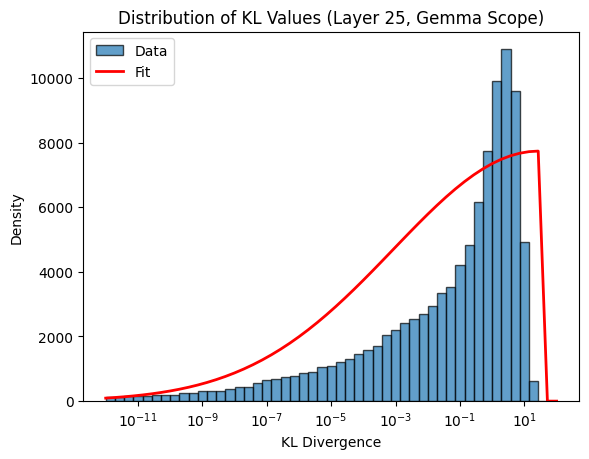

In [150]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# kl_values = np.clip(gemma_scope_validations.layer_results[26].kl, min=1e-16)
kl_values = gemma_scope_validations.layer_results[26].kl.astype(np.float32)
kl_values = kl_values[kl_values > 0]

# Take log of KL values to fit skew-normal distribution
log_kl = np.log(kl_values)

# Estimate skew-normal parameters using method of moments
# For skew-normal: mean, variance, and skewness
mean_log = np.mean(log_kl)
std_log = np.std(log_kl)
skewness = stats.skew(log_kl)

# Fit skew-normal distribution to log(kl_values)
# scipy's skewnorm uses (a, loc, scale) parameterization
# alpha, xi, omega = stats.skewnorm.fit(log_kl)
# alpha, xi, omega = stats.exponnorm.fit(log_kl)
# s, loc, scale = stats.lognorm.fit(kl_values)
loc, scale = stats.halfnorm.fit(-log_kl)
# loc, scale = stats.norm.fit(-log_kl)

# print(f"Estimated log-skew-normal parameters:")
# print(f"  xi (location): {xi:.4f}")
# print(f"  omega (scale): {omega:.4f}")
# print(f"  alpha (shape): {alpha:.4f}")

# Create histogram
plot_min = -12  # np.log10(np.min(kl_values))
plot_max = 2  # np.log10(np.max(kl_values))
log_bins = np.logspace(plot_min, plot_max, 50)
counts, _ = np.histogram(kl_values, bins=log_bins)
plt.hist(
    kl_values,
    bins=log_bins,
    edgecolor="black",
    alpha=0.7,
    label="Data",
)

# Plot fitted log-skew-normal PDF
x = np.logspace(plot_min, plot_max, 1000)
log_x = np.log(x)

# Skew-normal PDF for log(x), with Jacobian adjustment (1/x)
# pdf = stats.skewnorm.pdf(np.log(log_bins), alpha, loc=xi, scale=omega) * len(kl_values)
# pdf = stats.exponnorm.pdf(np.log(log_bins), alpha, loc=xi, scale=omega) * len(kl_values)
# pdf = stats.lognorm.pdf(np.log(log_bins), s, loc=loc, scale=scale) * len(kl_values)
pdf = stats.halfnorm.pdf(-np.log(log_bins), loc=loc, scale=scale) * len(kl_values)
# pdf = stats.norm.pdf(-np.log(log_bins), loc=loc, scale=scale) * len(kl_values)

plt.plot(log_bins, pdf, "r-", linewidth=2, label="Fit")
plt.xscale("log")
plt.xlabel("KL Divergence")
plt.ylabel("Density")
plt.title("Distribution of KL Values (Layer 25, Gemma Scope)")
plt.legend()
plt.show()

In [26]:
from transformers_sae.validation import generate_with_replacement

with torch.autocast(
    device_type="cuda" if model.device.type == "cuda" else "cpu",
    dtype=torch.bfloat16,
):
    generate_with_replacement(
        model,
        tokenizer,
        "The capital of France,",
        gemma_scope,
        # {},
        # {layer: sae for layer, sae in saes.items() if layer > 24},
    )

 Paris is one of the most beautiful and vibrant cities in the world. famous for its historic museums, museums XNUMX 1 

 1  1 1  1
  1
   1//​ 1
     1// </blockquote>

 1//
    // 
    
    //
    // 
     1////////////////////////////////////////


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from ipywidgets import interact, FloatSlider


def plot_log_skew_normal(xi=0.0, omega=1.0, alpha=0.0):
    """
    Plot the log skew-normal distribution.
    xi: location parameter
    omega: scale parameter (must be > 0)
    alpha: shape/skewness parameter
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Generate x values (positive only for log-skew-normal)
    x = np.logspace(-8, 2, 50000)

    # Log skew-normal PDF: transform through log
    # If Y ~ SkewNormal(xi, omega, alpha), then X = exp(Y) ~ LogSkewNormal
    log_x = np.log(x)

    # Skew-normal PDF for log(x)
    z = (log_x - xi) / omega
    pdf_skewnorm = (2 / omega) * stats.norm.pdf(z) * stats.norm.cdf(alpha * z)

    # Jacobian adjustment for log transformation: divide by x
    pdf = pdf_skewnorm / x

    ax.plot(x, pdf, "b-", linewidth=2)
    ax.fill_between(x, pdf, alpha=0.3)
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.set_title(
        f"Log Skew-Normal Distribution\nξ={xi:.2f}, ω={omega:.2f}, α={alpha:.2f}",
        fontsize=14,
    )
    ax.set_xlim(1e-10, 1e2)
    ax.set_ylim(0, max(pdf) * 1.1 if max(pdf) > 0 else 1)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


interact(
    plot_log_skew_normal,
    xi=FloatSlider(
        value=0.0, min=-30.0, max=30.0, step=0.01, description="ξ (location)"
    ),
    omega=FloatSlider(value=1.0, min=0.1, max=30.0, step=0.01, description="ω (scale)"),
    alpha=FloatSlider(
        value=0.0, min=-100.0, max=100.0, step=0.01, description="α (shape)"
    ),
);


interactive(children=(FloatSlider(value=0.0, description='ξ (location)', max=30.0, min=-30.0, step=0.01), Floa…